软件安装
```bash
pip install cmake boost
pip install dlib==19.19.0
pip install face_recognition
```

## 读取图像文件

使用face_recogntion自带的库文件读取图片

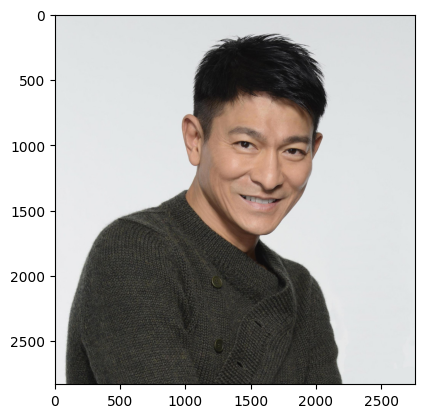

In [16]:
import face_recognition
import matplotlib.pyplot as plt

image = face_recognition.load_image_file("./Andy_Lau/1.jpg")

plt.imshow(image)
# plt.xticks([]);plt.yticks([])
plt.show()

使用opencv读取图片

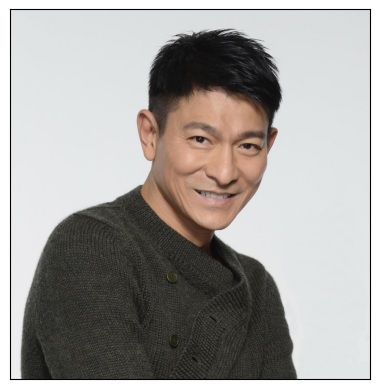

In [17]:
import cv2 as cv
import numpy as np

image = cv.imread("./Andy_Lau/1.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.imshow(image)
plt.xticks([]);plt.yticks([])
plt.show()


## 人脸检测
使用face_locations()检测人脸

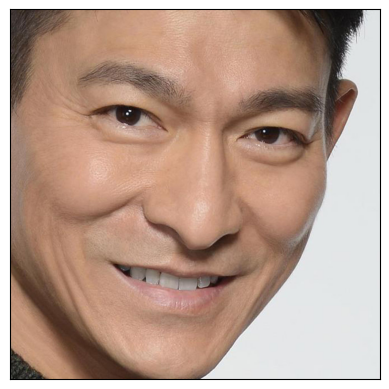

In [18]:
top,right,bottom,left = face_recognition.face_locations(image)[0]

plt.imshow(image[top:bottom,left:right,:])
plt.xticks([]);plt.yticks([])
plt.show()

使用opencv绘制人脸复选框

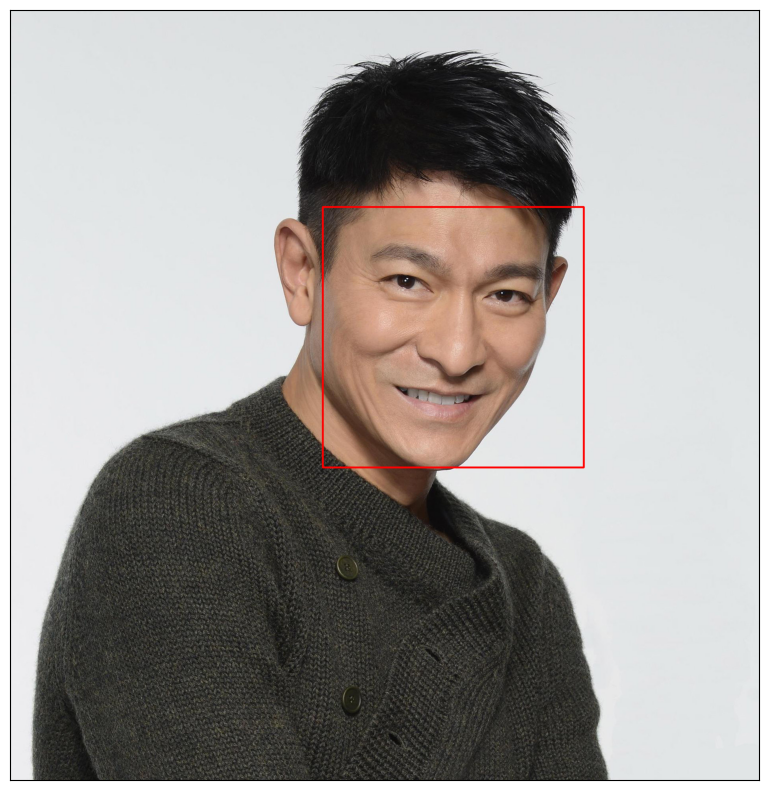

In [19]:
# 复制图像
image_c = np.copy(image)
# 绘制矩形框
cv.rectangle(image_c, (left,top),(right,bottom),(255,0,0),6)

# 可视化
plt.figure(figsize=(10,10))
plt.xticks([]);plt.yticks([])
plt.imshow(image_c)
plt.show()

多张人脸检测并框选

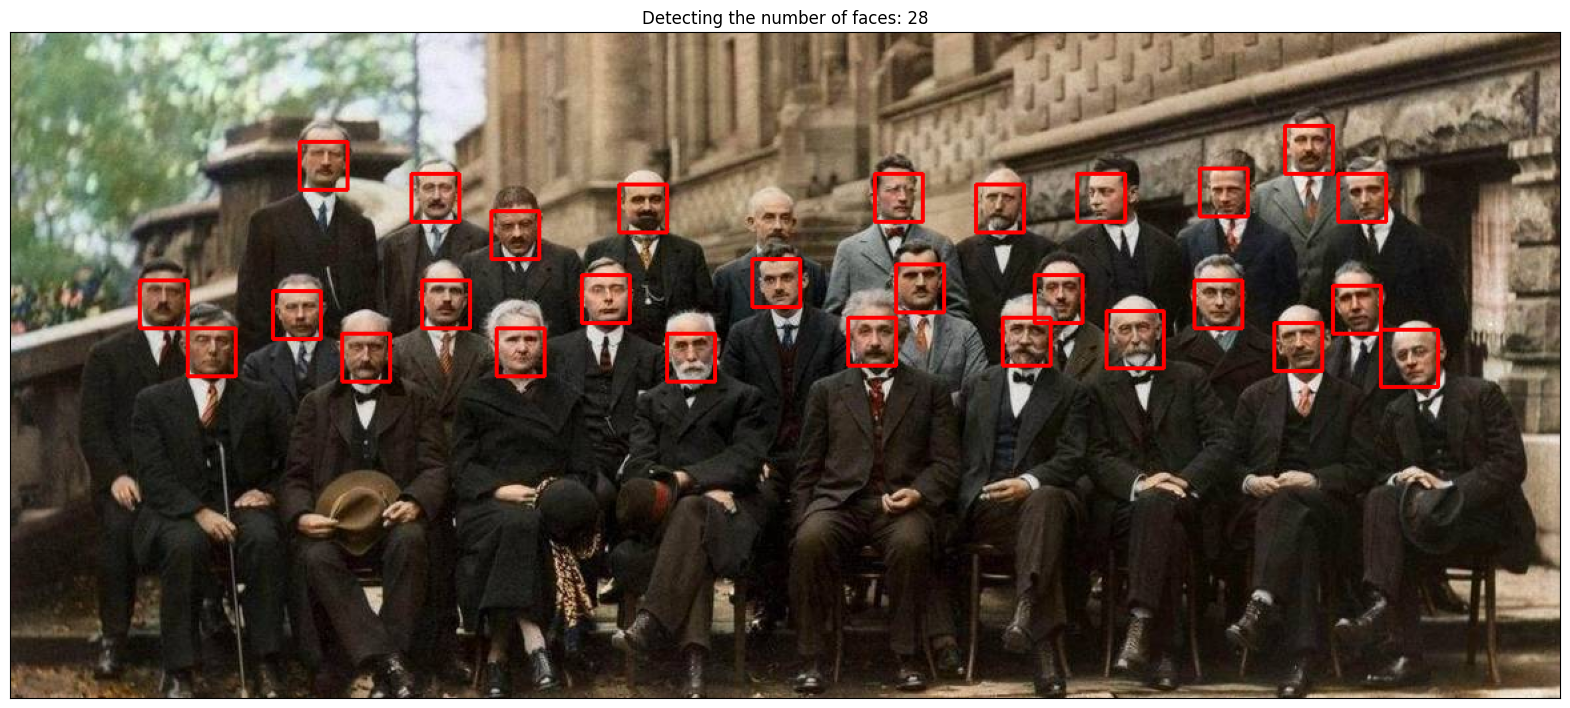

In [20]:
import face_recognition
import cv2 as cv
import matplotlib.pyplot as plt

# 读取图像
img = cv.imread("face.jpg")
irgb = cv.cvtColor(img,cv.COLOR_BGR2RGB)

# 人脸检测
box = face_recognition.face_locations(img)
# 绘制矩形框
for top,right,bottom,left in box:
    cv.rectangle(img, (left,top),(right,bottom),(0,0,255),2)

# 可视化
plt.figure(figsize=(20,40))
plt.imshow(img[:,:,::-1])
plt.title("Detecting the number of faces: {}".format(len(box)))
plt.xticks([]);plt.yticks([])
plt.show()


## 人脸关键点识别
使用face_recognition.face_landmarks()

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = face_recognition.load_image_file("./Andy_Lau/1.jpg")
face_landmarks_list = face_recognition.face_landmarks(image)

print(face_landmarks_list[0].keys())

dict_keys(['chin', 'left_eyebrow', 'right_eyebrow', 'nose_bridge', 'nose_tip', 'left_eye', 'right_eye', 'top_lip', 'bottom_lip'])


/tmp/ipykernel_9497/38956854.py:2: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  points = np.array(face_landmarks_list[0]["bottom_lip"],np.int)


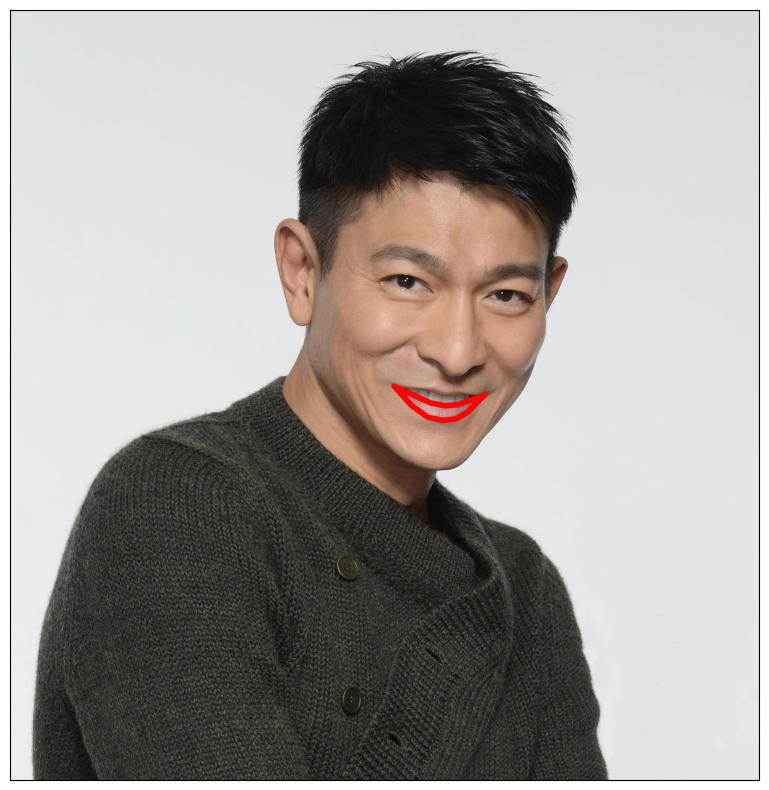

In [22]:
# 取出下嘴唇的点
points = np.array(face_landmarks_list[0]["bottom_lip"],np.int)
# 绘制多段线
cv.polylines(image,[points],False,(255,0,0),20)

# 可视化
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.xticks([]);plt.yticks([])
plt.show()

多个人脸关键点标记

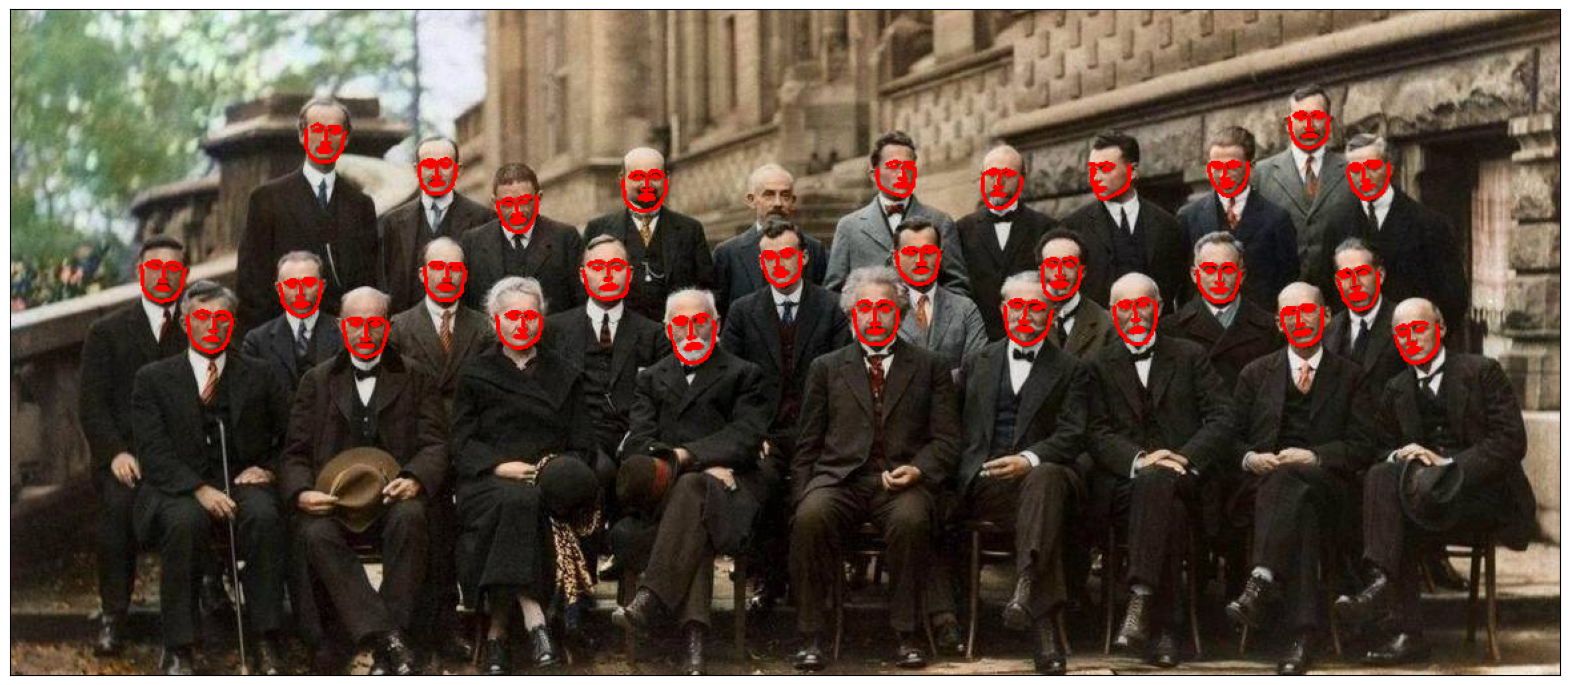

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("face.jpg")
irgb = cv.cvtColor(img,cv.COLOR_BGR2RGB)

face_landmarks_list = face_recognition.face_landmarks(irgb)

for mark in face_landmarks_list:
    for key in mark.keys():
        points = np.array(mark[key])
        cv.polylines(img,[points],False,(0,0,255),2)

plt.figure(figsize=(20,10))
plt.xticks([]),plt.yticks([])
plt.imshow(img[:,:,::-1])
plt.show()

## 识别人脸
在进行人脸识别之前，需要将人脸进行编码，我们使用face_recognition.face_encodings()方法将人脸编码

In [24]:
import face_recognition
import matplotlib.pyplot as plt
known_image = face_recognition.load_image_file("./Andy_Lau/1.jpg")
Andylau_encoding = face_recognition.face_encodings(known_image)[0]


使用face_recognition.compare_faces()匹配人脸，这里需要先对加载一张人脸与之匹配，同理需要将他编码。

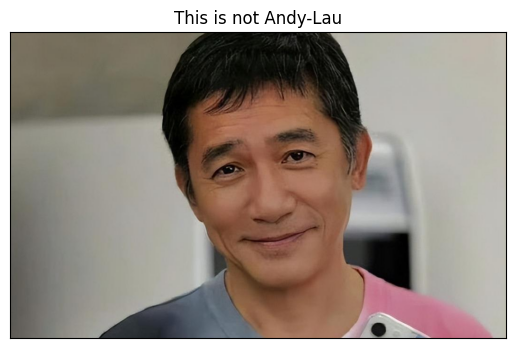

In [25]:
# 加载未知图像
unknown_image = face_recognition.load_image_file("./Tony_Leung/2.jpeg")
# 图像中的人脸编码
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]
# 人脸匹配
results = face_recognition.compare_faces([Andylau_encoding], unknown_encoding,0.5)

# 可视化部分
plt.imshow(unknown_image)
plt.xticks([]),plt.yticks([])
if results[0] == True:
    plt.title("This is Andy-Lau")
else:
    plt.title("This is not Andy-Lau")
plt.show()

## 检测并识别多张人脸

将已知人脸编码，存储在列表中

In [26]:
import face_recognition

known_face_encodings = []
known_face_names=[]

def load_face_encodings(path,name):
    known_image = face_recognition.load_image_file(path)
    known_encoding = face_recognition.face_encodings(known_image)[0]
    known_face_encodings.append(known_encoding)
    known_face_names.append(name)

load_face_encodings("./Andy_Lau/1.jpg","Andy_Lau")
load_face_encodings("./Tony_Leung/1.jpeg","Tony_Leung")

加载需要识别的图像并将识别到的人脸进行编码

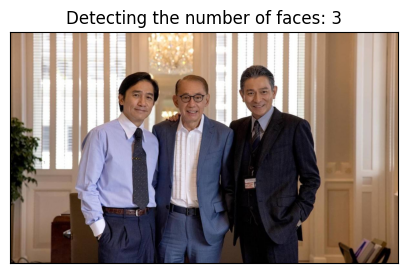

In [27]:
import matplotlib.pyplot as plt

# 加载图像
image = face_recognition.load_image_file("./unknown.jpeg")
# 检测人脸
face_locations = face_recognition.face_locations(image)
# 将检测到的人脸进行编码
unknown_encodings = face_recognition.face_encodings(image,face_locations)

# 可视化
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Detecting the number of faces: {}".format(len(face_locations)))
plt.xticks([]),plt.yticks([])
plt.show()

将检测到的人脸与已知人脸进行识别

In [28]:
import numpy as np

face_names = []
num = 0
for unknown_encoding in unknown_encodings:
    num += 1
    print("***********第%d张人脸***********"%num)
    # 计算与已知人脸的误差
    face_distances = face_recognition.face_distance(known_face_encodings,unknown_encoding)
    print("与已知人脸编码距离： {}".format(face_distances))
    best_match_index = np.argmin(face_distances)
    print("与已知人脸编码距离最小索引为： {}".format(best_match_index))
    # 匹配人脸
    matches = face_recognition.compare_faces(known_face_encodings, unknown_encoding,0.5)
    print("与已知人脸编码匹配结果： {}".format(matches))
    if matches[best_match_index]:
        face_names.append(known_face_names[best_match_index])
    else:
        face_names.append("unknown")


***********第1张人脸***********
与已知人脸编码距离： [0.54581357 0.30284371]
与已知人脸编码距离最小索引为： 1
与已知人脸编码匹配结果： [False, True]
***********第2张人脸***********
与已知人脸编码距离： [0.40094311 0.49471009]
与已知人脸编码距离最小索引为： 0
与已知人脸编码匹配结果： [True, True]
***********第3张人脸***********
与已知人脸编码距离： [0.75230514 0.60014006]
与已知人脸编码距离最小索引为： 1
与已知人脸编码匹配结果： [False, False]


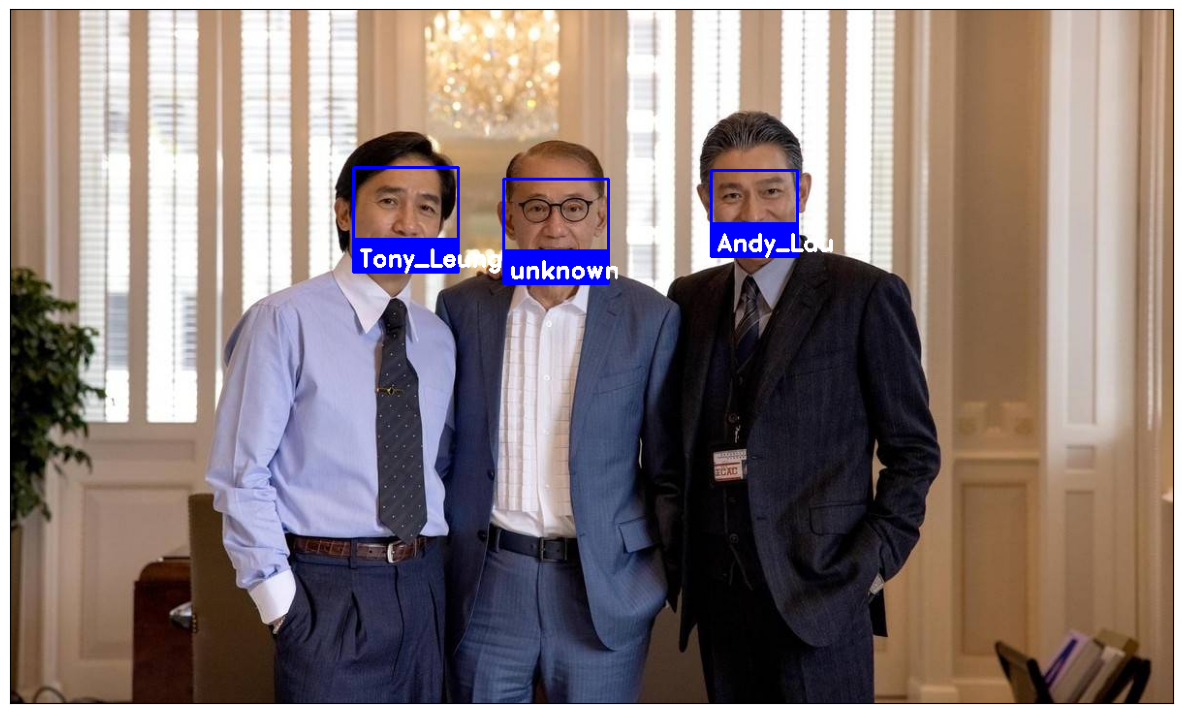

In [29]:
import cv2 as cv
import numpy as np

# 复制图像
image_c = np.copy(image)

for (top, right, bottom, left), name in zip(face_locations, face_names):
    # 绘制人脸框
    cv.rectangle(image_c, (left,top),(right,bottom),(0,0,255),2)
    # 绘制文本底纹
    cv.rectangle(image_c, (left, bottom - 35), (right, bottom), (0, 0, 255), cv.FILLED)
    # 绘制人脸标签
    font = cv.FONT_HERSHEY_DUPLEX
    cv.putText(image_c,name,(left + 6, bottom - 6), font, 0.8,(255,255,255), 2)

plt.figure(figsize=(15,15))
plt.imshow(image_c)
plt.xticks([]);plt.yticks([])
plt.show()

In [30]:
face_locations

[(163, 462, 271, 354), (166, 812, 255, 723), (175, 617, 283, 509)]